In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append('../../scripts')

import readwrite
cfg = readwrite.config()


def get_logfc_summary(ads, gene_malignant, level, ct_malignant):
    """
    Calculates the mean log Fold Change of a gene between malignant and non-malignant cells.
    """
    results = []
    for correction_method, ad_group in ads.items():
        for k, ad in ad_group.items():
            # Unpack the key to get metadata
            segmentation, condition, panel, donor, sample = k

            # Prepare a temporary DataFrame for this sample
            df_sample = ad.obs.copy()
            df_sample[gene_malignant] = ad[:, gene_malignant].X.toarray().ravel()

            # Create a new column with string labels
            df_sample['is_malignant'] = np.where(df_sample[level] == ct_malignant, "Malignant", "Non-Malignant")

            # Calculate the mean expression using the labels
            mean_expression = df_sample.groupby('is_malignant')[gene_malignant].mean()

            mean_malignant = mean_expression["Malignant"]
            mean_non_malignant = mean_expression["Non-Malignant"]
            logfc = mean_malignant - mean_non_malignant

            # Append the summary result for this sample to our list
            results.append({
                'logFC': logfc,
                'correction_method': correction_method,
                'segmentation': segmentation,
                'condition': condition,
                'panel': panel,
                'sample_id': f"{donor}_{sample}"
            })

    # Convert the list of results into a clean pandas DataFrame for plotting
    df_summary = pd.DataFrame(results)
    return df_summary


def plot_logfc_summary(df_summary, gene_malignant, correction_methods):
    """
    Generates a grouped boxplot showing the logFC across different conditions.
    """
    plt.figure(figsize=(10, 7))

    # Use seaborn.boxplot for the main plot
    ax = sns.boxplot(
        data=df_summary,
        x='segmentation',
        y='logFC',
        hue='correction_method',
        showfliers=False,
        hue_order=correction_methods
    )

    # Overlay a stripplot to show each individual sample as a dot
    sns.stripplot(
        data=df_summary,
        x='segmentation',
        y='logFC',
        hue='correction_method',
        dodge=True,
        ax=ax,
        palette='dark:black',
        size=6,
        edgecolor='gray',
        linewidth=0.5,
        hue_order=correction_methods

    )

    # --- Plot Aesthetics ---
    ax.set_title(f'Mean logFC of {gene_malignant} Expression (Malignant vs. Non-Malignant)', fontsize=16)
    ax.set_ylabel(f'Mean log({gene_malignant}) Difference')
    ax.set_xlabel('Segmentation Method')

    # Improve the legend
    handles, labels = ax.get_legend_handles_labels()
    n_methods = len(correction_methods)
    plt.legend(handles[0:n_methods], labels[0:n_methods], title='Correction Method', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Add a horizontal line at y=0 for reference (no change)
    ax.axhline(0, ls='--', color='grey')

    plt.tight_layout()
    plt.show()

def get_expression_df(
    ads: dict,
    gene: str,
    level: str,
    ct_malignant: str
) -> pd.DataFrame:
    all_dfs = []
    for correction_method, ad_group in ads.items():
        for k, ad in ad_group.items():
            segmentation, condition, panel, donor, sample = k
            is_malignant_str = np.where(ad.obs[level].values == ct_malignant, "Malignant", "Non-Malignant")
            df_sample = pd.DataFrame({
                gene: ad[:, gene].X.toarray().ravel(),
                'is_malignant': is_malignant_str
            })
            df_sample['correction_method'] = correction_method
            df_sample['segmentation'] = segmentation
            df_sample['condition'] = condition
            df_sample['panel'] = panel
            df_sample['donor'] = donor
            df_sample['sample'] = sample
            all_dfs.append(df_sample)
    return pd.concat(all_dfs, ignore_index=True)


def plot_expression_distribution(
    df_plot: pd.DataFrame,
    gene: str,
    x: str = 'segmentation',
    hue: str = 'correction_method',
    facet: str = 'is_malignant',
    showfliers=True,
):
    """
    Generates faceted boxplots with independent y-axes to show expression
    distributions for malignant and non-malignant cells separately.

    Args:
        df_plot: Aggregated DataFrame from prepare_expression_df.
        gene: The gene being plotted (for labels).
        x: The column for the x-axis.
        hue: The column for the color grouping within each subplot.
        facet: The column used to create separate subplots.
    """

    g = sns.catplot(
        data=df_plot,
        x=x,
        y=gene,
        hue=hue,
        col=facet,
        col_order=['Non-Malignant', 'Malignant'],
        kind='box',
        showfliers=showfliers,
        height=7,
        aspect=1.2,
        palette='muted',
        legend_out=True,
        sharey=False
    )

    # --- Aesthetics and Titles ---
    g.fig.suptitle(f'Distribution of {gene} Expression', y=1.03, fontsize=20, weight='bold')
    
    # Set labels for the figure
    g.set_axis_labels(x.replace('_', ' ').title(), f"log({gene}) Expression")
    g.set_titles("Cell Status: {col_name}", size=16)
    g.set_xticklabels(rotation=30, ha='right')

    # Iterate through the axes to apply custom settings to each subplot
    for ax in g.axes.flat:
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.tick_params(axis='both', labelsize=12)

    # Adjust the legend
    if g._legend is not None:
        g._legend.set_title(hue.replace('_', ' ').title())
        plt.setp(g._legend.get_title(), fontsize='large') # Make legend title bigger
        plt.setp(g._legend.get_texts(), fontsize='medium')  # Make legend text bigger

    g.fig.subplots_adjust(right=0.85)
    plt.show()

### Paths and parameters

In [ ]:
# paths
xenium_dir = Path(cfg['xenium_processed_dir'])
xenium_count_correction_dir = Path(cfg['xenium_count_correction_dir'])
xenium_std_seurat_analysis_dir = Path(cfg['xenium_std_seurat_analysis_dir'])
xenium_cell_type_annotation_dir = Path(cfg['xenium_cell_type_annotation_dir'])
results_dir = Path(cfg['results_dir'])

# parameters
xenium_levels = ['segmentation','condition','gene panel','donor','sample']
correction_methods = ['raw','SPLIT']
# segmentations = ['10x_5um','proseg']
normalisation = 'lognorm'
layer = 'data'
reference = 'GEO_GSE178341'
method = 'rctd_class_aware'
level = 'Level1'
gene_malignant = 'EPCAM'
ct_malignant = 'Epi'

### Read all xenium samples

In [ ]:
# get paths
xenium_paths, xenium_annot_paths = readwrite.discover_xenium_paths(
    analysis_dir=xenium_std_seurat_analysis_dir,
    data_dir=xenium_dir,
    annotation_dir=xenium_cell_type_annotation_dir,
    correction_dir=xenium_count_correction_dir,
    normalisation=normalisation,
    reference=reference,
    method=method,
    level=level,

    # (optional) read only some parameter combinations
    correction_methods_filter=correction_methods,
    # segmentations_filter=segmentations,
    # conditions_filter=,
    # panels_filter=
)

# read corrected counts
ads = readwrite.read_count_correction_samples(xenium_paths,[c for c in correction_methods if c != 'raw'])
ads['SPLIT'] = ads.pop('split_fully_purified') #rename SPLIT method

# read raw counts
ads['raw'] = readwrite.read_xenium_samples(
    xenium_paths['raw'],  
    anndata=True, 
    pool_mode="thread",
    max_workers=6
)

# add cell type annotation from raw to all correction methods
readwrite.read_annotations(ads, correction_methods, xenium_annot_paths, level, max_workers=8)

# log-normalize raw counts
for correction_method in correction_methods:
    for k,ad in ads[correction_method].items():
        print(correction_method,k)
        
        sc.pp.normalize_total(ad)
        sc.pp.log1p(ad)

Processing split_fully_purified: 100%|██████████| 176/176 [00:30<00:00,  5.81it/s]
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_polygons', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/

INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_5um/CRC/
         hImmune_v1_mm/OIYM/HCC_output-XETG00209__0003786__OIYM__20250503__073331/normalised_results/outs/cell_feat
         ure_matrix.h5                                                                                             


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_5um/CRC/
         hImmune_v1_mm/1EGQ/output-XETG00059__0053261__1EGQ__20250306__164822/normalised_results/outs/cell_feature_
         matrix.h5                                                                                                 


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_polygons', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.11/site-packages/anndata/_core/anndata.py:812: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  names = self._prep_dim_index(names, "obs")


...

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_0um/CRC_
         PDO/hImmune_v1_mm/OUC1/output-XETG00059__0021738__OUC1__20250319__172035/normalised_results/outs/cell_feat
         ure_matrix.h5                                                                                             
INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_0um/CRC_
         PDO/hImmune_v1_mm/OAFN/output-XETG00059__0021738__OAFN__20250319__172035/normalised_results/outs/cell_feat
         ure_matrix.h5                                                                                             


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_0um/CRC_
         PDO/hImmune_v1_mm/O056/output-XETG00059__0021741__O056__20250319__172035/normalised_results/outs/cell_feat
         ure_matrix.h5                                                                                             


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/norkin-organoid/lib/python3.11/site-packages/spatialdat

/tmp/ipykernel_771064/2127189992.py:70: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


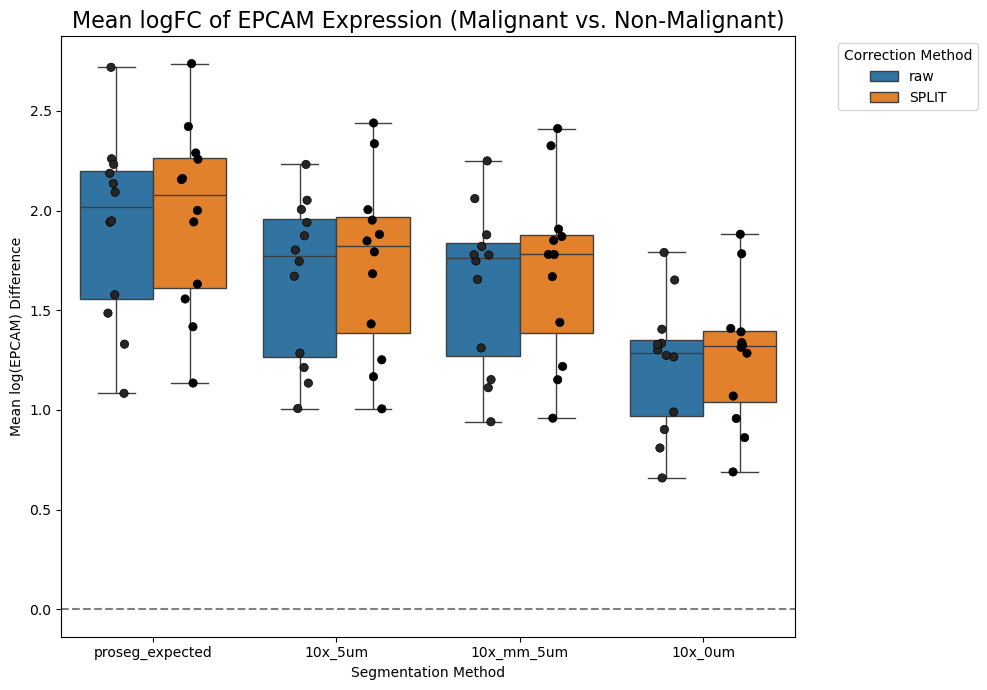

/tmp/ipykernel_771064/2127189992.py:70: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


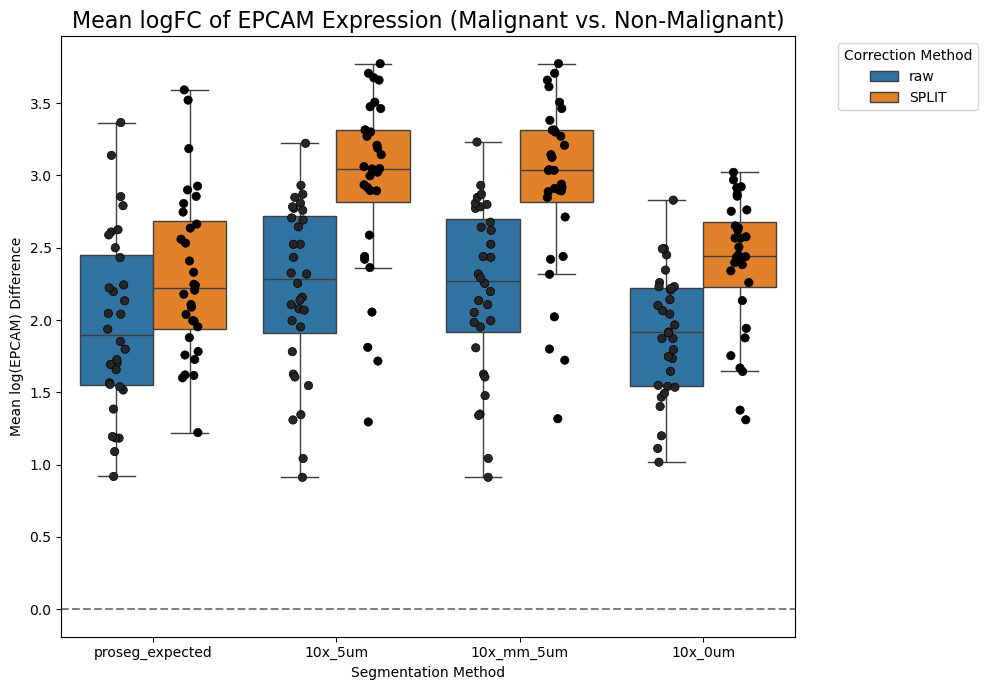

In [57]:
df_summary = get_logfc_summary(
    ads=ads,
    gene_malignant=gene_malignant,
    level=level,
    ct_malignant=ct_malignant
)

plot_logfc_summary(df_summary.query('condition == "CRC"'), gene_malignant, correction_methods)
plot_logfc_summary(df_summary.query('condition == "CRC_PDO"'), gene_malignant, correction_methods)

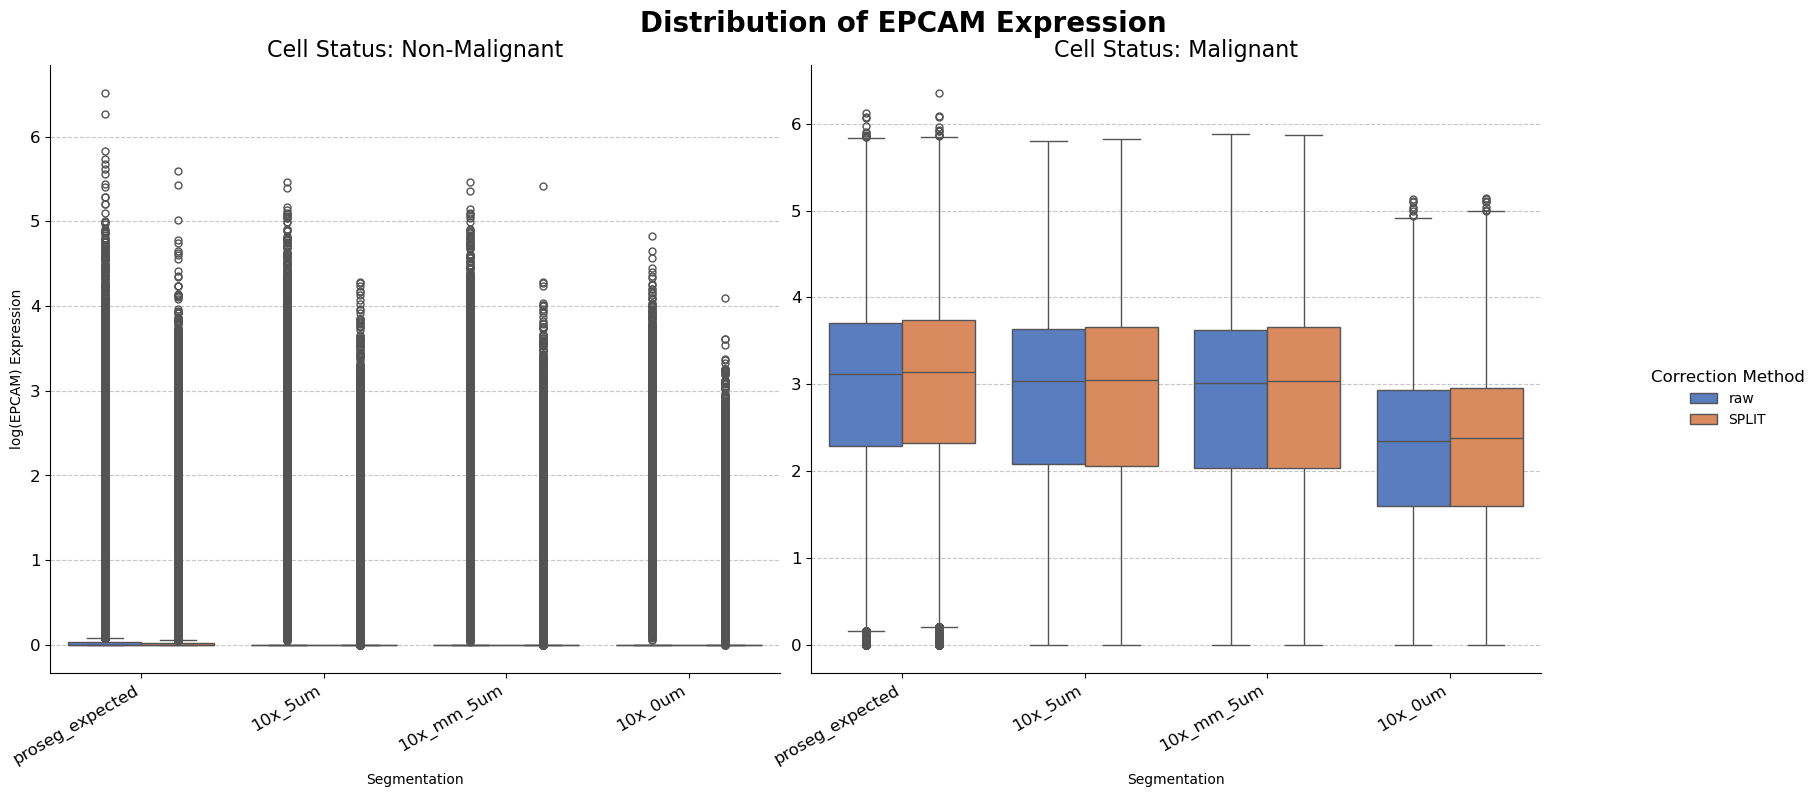

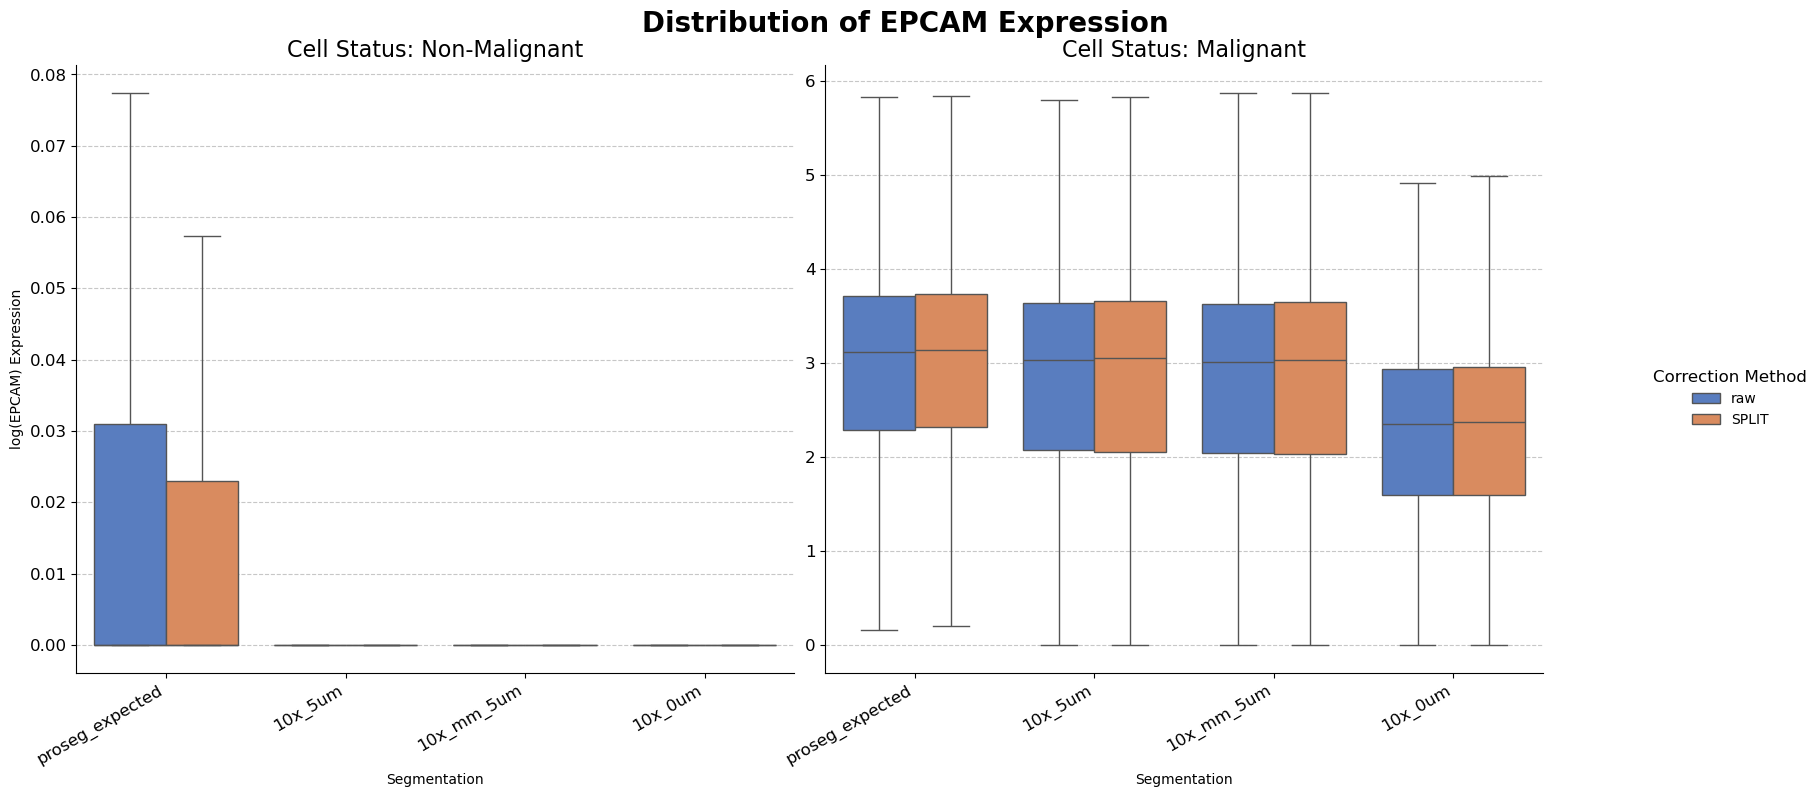

In [84]:
df_plot = get_expression_df(
    ads=ads,
    gene=gene_malignant,
    level=level,
    ct_malignant=ct_malignant
)

plot_expression_distribution(df_plot, gene=gene_malignant,showfliers=True)
plot_expression_distribution(df_plot, gene=gene_malignant,showfliers=False)